In this notebook, we demonstrate the application of 4D-Var on the KS system, where the dynamical core is imported from a JAX solver exponax[1]. We bridge the gradient propagation between adda which is written in torch and exponax which is written in JAX. Python 3.10, exponax and jax are necessary to run this notebook.

[1] https://github.com/Ceyron/exponax

2D KS system:

$$\frac{\partial u}{\partial t} + \frac{1}{2} \| \nabla u \|_2^2 + \Delta u + \Delta^2 u = 0$$



In [1]:
import os
import torch
import jax
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import HTML
from tensordict import TensorDict
from time import time
import exponax as ex
import exponax.stepper as st
os.chdir('..')
from adda.convert.jax import j2t, t2j, jax_to_torch_fn
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.util.visualization import show_1dseqimg
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.probability.distributions import DiagonalGaussian

# Generation of groundtruth data

In [2]:
torch.backends.cudnn.deterministic = True
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Experiment parameters
DOMAIN_EXTENT = 30.0
NUM_POINTS = 100
DT = 0.15
ks_stepper = ex.stepper.KuramotoSivashinsky(2, DOMAIN_EXTENT, NUM_POINTS, DT)
tot_warmup = 1000
tot_steps = 159

In [3]:
# We create the jax solver and wrap a torch class around it for gradient propagation.
forward_operator_torch_warmup = jax_to_torch_fn(jax.jit(ex.repeat(ks_stepper, tot_warmup)))
forward_operator_torch = jax_to_torch_fn(jax.jit(ex.rollout(ks_stepper, tot_steps, include_init=True)))
# There is an additional batch dimension which is 1, we parallelize using jax.vmap because of this.
jax_forward_assimilate = jax.jit(ex.rollout(ks_stepper, 1, include_init=True))
jax_batched_forward_assimilate = jax.jit(
    jax.vmap(jax_forward_assimilate, in_axes=0)
)

forward_assimilate = jax_to_torch_fn(
    jax_batched_forward_assimilate
)

In [4]:
# We create the ICs using jax arrays.
grid = ex.make_grid(2, DOMAIN_EXTENT, NUM_POINTS)
u_0 = jax.random.normal(jax.random.PRNGKey(0), (1, NUM_POINTS, NUM_POINTS))
# And convert them to Torch tensors.
initial_state = j2t(u_0)
initial_state = initial_state.to(device)
print("Initial Condition Shape: ", initial_state.shape)
# Burn-in period.
ks_warmed_up = forward_operator_torch_warmup(initial_state)
print("Last Burnin State Shape: ", ks_warmed_up.shape)
ks_series = forward_operator_torch(ks_warmed_up)
print("Complete Series Shape: ", ks_series.shape)

Initial Condition Shape:  torch.Size([1, 100, 100])
Last Burnin State Shape:  torch.Size([1, 100, 100])
Complete Series Shape:  torch.Size([160, 1, 100, 100])


In [ ]:
ks_series_jax = t2j(ks_series)
ks_ani = ex.viz.animate_state_2d(ks_series_jax, vlim=(-6, 6))
HTML(ks_ani.to_jshtml())

In [6]:
tot_timesteps = ks_series.shape[0]
forecast_steps = torch.arange(0, tot_timesteps * DT, DT)
true_series = State(ks_series.unsqueeze(0), time_axis=forecast_steps)
print("Shape of the Ground Truth Series: ", true_series.shape)

Shape of the Ground Truth Series:  {'x': torch.Size([1, 160, 1, 100, 100])}


# Strong-constraint 4D-var

In [7]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)
print("Observations Shape: ", observations.state.fields['x'].shape)

Observations Shape:  torch.Size([1, 160, 1, 100, 100])


In [8]:
n_obs_steps = 16 # we assimilate only on the earliest time steps for the single window strong constraint 4D-Var, otherwise the optimization would be too unstable.
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])
obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

### Visualization of the Noisy Observations

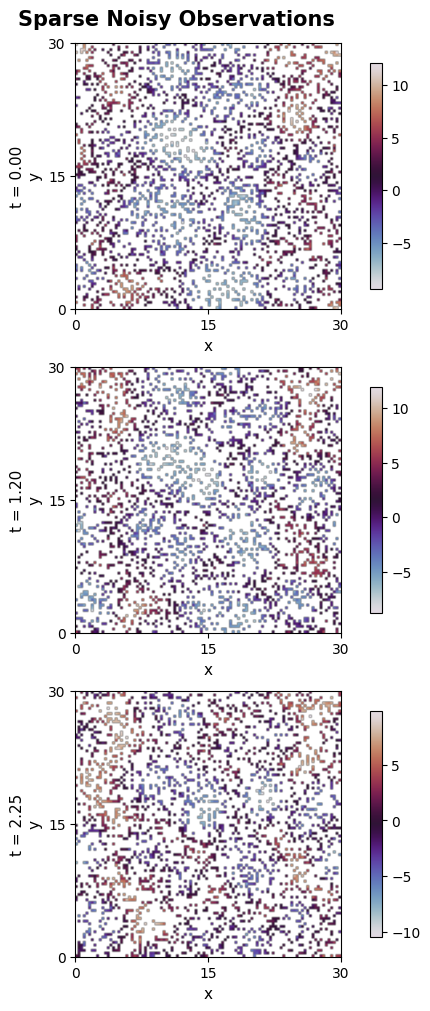

In [9]:
times = [0, n_obs_steps // 2, n_obs_steps - 1]
cmap = 'twilight'

data = [
    observations.state.fields['x'][0, t, 0].detach().cpu().numpy()
    for t in times
]
row_labels = [f't = {times[i] * DT:.2f}' for i in range(3)]
fig, ax = plt.subplots(3, 1, figsize=(5, 10), constrained_layout=True)
fig.suptitle('Sparse Noisy Observations', fontsize=15, fontweight='bold')

for i in range(3):
    im = ax[i].imshow(
        data[i],
        cmap=cmap,
        extent=(0, DOMAIN_EXTENT, 0, DOMAIN_EXTENT),
        origin='lower',
    )
    ax[i].set_xlabel('x', fontsize=11)
    ax[i].set_ylabel(f'{row_labels[i]}\ny', fontsize=11)
    ax[i].set_xticks([0, DOMAIN_EXTENT//2, DOMAIN_EXTENT])
    ax[i].set_yticks([0, DOMAIN_EXTENT//2, DOMAIN_EXTENT])
    fig.colorbar(im, ax=ax[i], shrink=0.85)

plt.show()

In [10]:
# In order to use the 4D-Var function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, 1, NUM_POINTS, NUM_POINTS)
    # print("input.shape:", input.shape)  # should be (1, 1, NUM_POINTS, NUM_POINTS)
    integrated = forward_assimilate(input)[:, -1] # integrate over a time step, take the current time
    # print("integrated.shape:", integrated.shape)  # should be (1, 1, NUM_POINTS, NUM_POINTS)
    integrated = integrated.reshape(B, T, 1, NUM_POINTS, NUM_POINTS)
    # print("integrated.shape after reshape:", integrated.shape)  # should be (1, 1, 1, NUM_POINTS, NUM_POINTS)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + DT)  # return State object, advancing time

In [11]:
initialization = naive_initialization(observations_opt, default_value=0) # naive initialization on the firt time step of the time series
initialization = initialization[:, :1] # we only initialize the first time step, the rest will be optimized
print("Shape of the Initial Guess: ", initialization.shape)

Shape of the Initial Guess:  {'x': torch.Size([1, 1, 1, 100, 100])}


In [12]:
t0 = time()
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt, 
                                       obs_op_opt, 
                                       initialization,                                        
                                       optimizer_pars={'lr': 1e-1},
                                       verbose=1,
                                       n_steps=5)                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

iteration 0: loss = 78765.2578125
iteration 0: loss = 78736.984375
iteration 0: loss = 75332.3828125
iteration 0: loss = 71888.734375
iteration 0: loss = 68423.90625
iteration 0: loss = 65065.4140625
iteration 0: loss = 61900.3671875
iteration 0: loss = 58989.6796875
iteration 0: loss = 56366.34375
iteration 0: loss = 54035.29296875
iteration 0: loss = 51980.1796875
iteration 0: loss = 50175.42578125
iteration 0: loss = 48596.515625
iteration 0: loss = 47225.16015625
iteration 0: loss = 46048.84375
iteration 0: loss = 45055.1875
iteration 0: loss = 44222.41015625
iteration 0: loss = 43514.7265625
iteration 0: loss = 42893.71875
iteration 0: loss = 42334.75390625
iteration 1: loss = 41827.0390625
iteration 1: loss = 41363.890625
iteration 1: loss = 40939.1484375
iteration 1: loss = 40548.0390625
iteration 1: loss = 40187.04296875
iteration 1: loss = 39852.5859375
iteration 1: loss = 39511.34765625
iteration 1: loss = 39229.2890625
iteration 1: loss = 38995.50390625
iteration 1: loss = 3

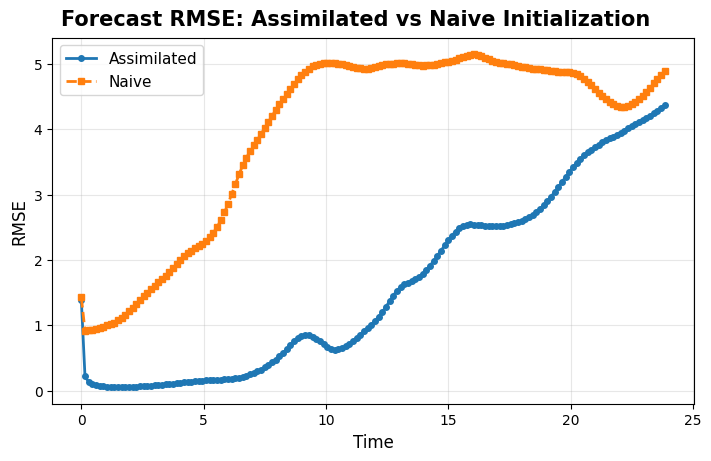

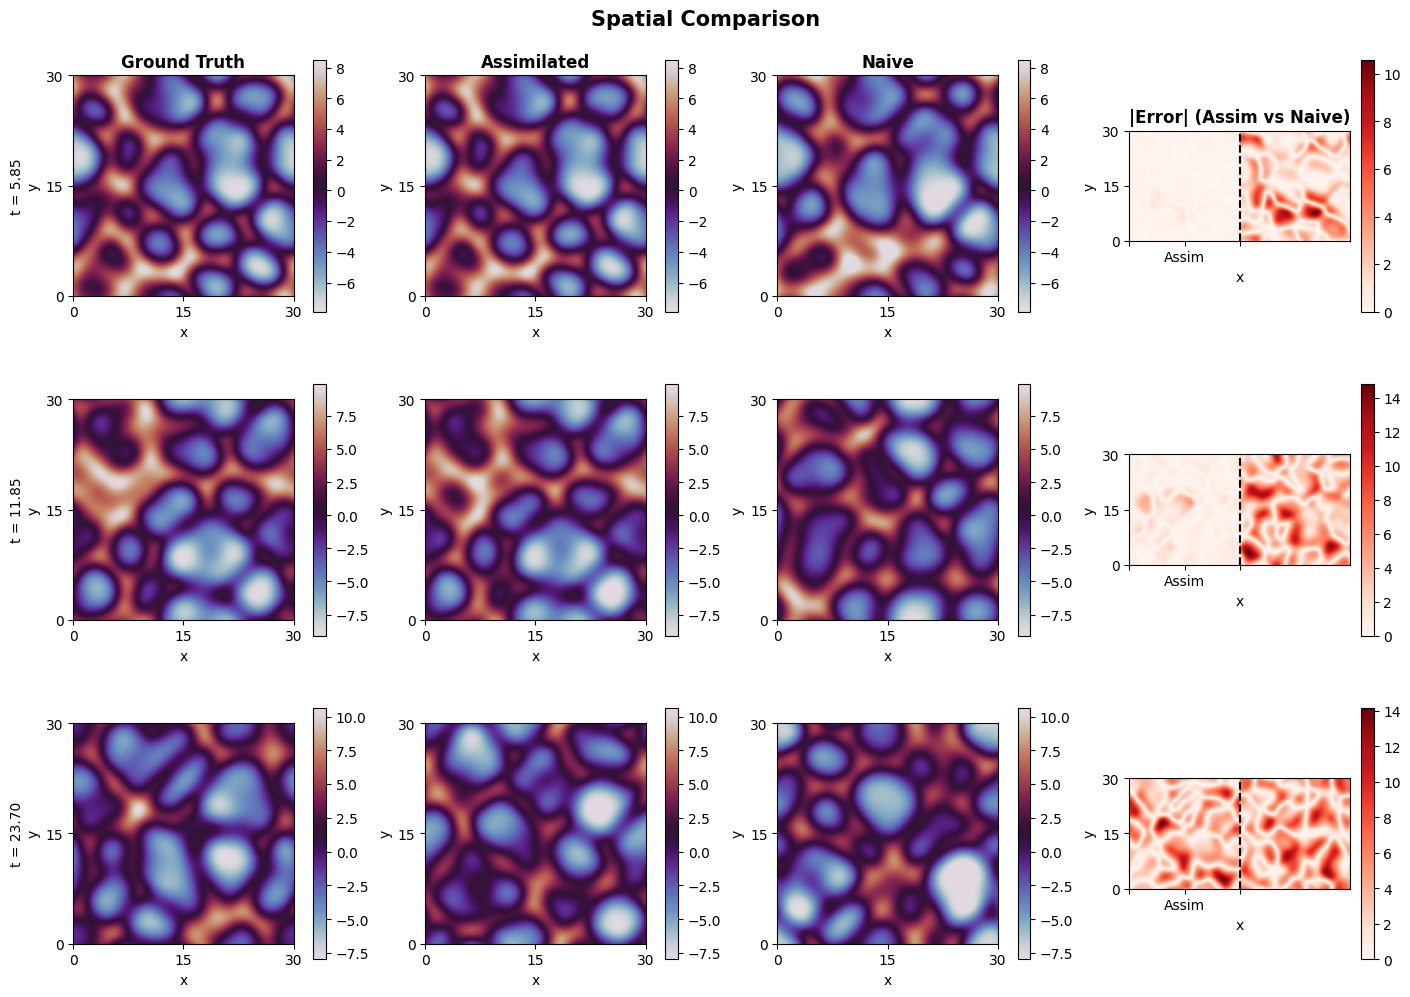

Metric                     Assimilated IC        Naive IC
---------------------------------------------------------
Mean RMSE                          1.5935          3.9525
Final RMSE                         4.3671          4.8928


In [13]:
n_forecast=tot_steps
# We generate the trajectories from the assimilated initial condition and the initial guess to see how they compare with the true trajectory.
assim_input = assimilated_ic.fields['x'].squeeze(0, 1).detach()
initialization_input = initialization.fields['x'].squeeze(0, 1).detach()
pred_assim = forward_operator_torch(assim_input)
pred_naive = forward_operator_torch(initialization_input)
gt_window = ks_series

channel = 0

def rmse_over_time(pred, gt):
    """Compute spatial RMSE at each timestep for a single channel."""
    diff = (pred.detach() - gt).cpu().numpy()
    rmse = np.sqrt((diff[:, channel] ** 2).mean(axis=(1, 2)))
    return rmse

rmse_assim = rmse_over_time(pred_assim, gt_window)
rmse_naive = rmse_over_time(pred_naive, gt_window)

# Plot 1: RMSE over time
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
fig.suptitle(
    'Forecast RMSE: Assimilated vs Naive Initialization',
    fontsize=15,
    fontweight='bold',
)

ax.plot(forecast_steps, rmse_assim, 'o-', label='Assimilated', linewidth=2, markersize=4)
ax.plot(forecast_steps, rmse_naive, 's--', label='Naive', linewidth=2, markersize=4)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.show()

# Plot 2: Spatial comparison at 3 time snapshots
snap_times = [n_forecast // 4, n_forecast // 2, n_forecast - 1]
cmap = 'twilight'
cmap_err = 'Reds'

fig, ax = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)
fig.suptitle(
    'Spatial Comparison',
    fontsize=15,
    fontweight='bold',
)

col_titles = [
    'Ground Truth',
    'Assimilated',
    'Naive',
    '|Error| (Assim vs Naive)',
]

for j, title in enumerate(col_titles):
    ax[0, j].set_title(title, fontsize=12, fontweight='bold')

for i, t in enumerate(snap_times):
    gt_field = gt_window[t, channel].cpu().numpy()
    assim_field = pred_assim[t, channel].cpu().detach().numpy()
    naive_field = pred_naive[t, channel].cpu().detach().numpy()

    err_assim = np.abs(assim_field - gt_field)
    err_naive = np.abs(naive_field - gt_field)
    err_max = max(err_assim.max(), err_naive.max())

    vmin, vmax = gt_field.min(), gt_field.max()

    for j, field in enumerate([gt_field, assim_field, naive_field]):
        im = ax[i, j].imshow(
            field,
            cmap=cmap,
            extent=(0, DOMAIN_EXTENT, 0, DOMAIN_EXTENT),
            origin='lower',
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(im, ax=ax[i, j], shrink=0.85)

    err_combined = np.concatenate([err_assim, err_naive], axis=1)

    im = ax[i, 3].imshow(
        err_combined,
        cmap=cmap_err,
        extent=(0, DOMAIN_EXTENT*2, 0, DOMAIN_EXTENT),
        origin='lower',
        vmin=0,
        vmax=err_max,
    )
    ax[i, 3].axvline(DOMAIN_EXTENT, color='k', linewidth=1.5, linestyle='--')
    ax[i, 3].set_xticks([DOMAIN_EXTENT//2, DOMAIN_EXTENT + DOMAIN_EXTENT//2 ])
    ax[i, 3].set_xticklabels(['Assim', 'Naive'], fontsize=10)
    fig.colorbar(im, ax=ax[i, 3], shrink=0.85)

    for j in range(4):
        ax[i, j].set_xticks([0, DOMAIN_EXTENT//2 , DOMAIN_EXTENT])
        ax[i, j].set_yticks([0, DOMAIN_EXTENT//2 , DOMAIN_EXTENT])
        ax[i, j].set_xlabel('x', fontsize=10)
        ax[i, j].set_ylabel(
            f't = {t * DT:.2f}\ny' if j == 0 else 'y',
            fontsize=10,
        )

plt.show()

# Summary
print(f"{'Metric':<25} {'Assimilated IC':>15} {'Naive IC':>15}")
print("-" * 57)
print(f"{'Mean RMSE':<25} {rmse_assim.mean():>15.4f} {rmse_naive.mean():>15.4f}")
print(f"{'Final RMSE':<25} {rmse_assim[-1]:>15.4f} {rmse_naive[-1]:>15.4f}")